In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

/home/pacto/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Leitura da imagem, alguns exemplos
img = np.random.randint(0,255,(512,512),dtype=np.uint8) #img 512x512, uint8 aleatorios
#img = cv2.imread('./airfield-05small-auto.tif', cv2.IMREAD_GRAYSCALE) # tif, com perdas
#img = cv2.imread('./lena.png', cv2.IMREAD_GRAYSCALE) # velha lena nunca falha, sem perdas, png

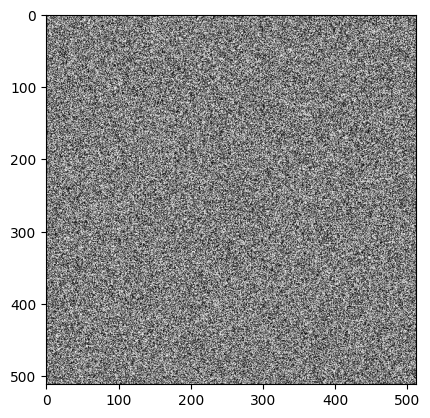

In [3]:
plt.figure(0)
plt.imshow(img, cmap='gray') # especificar color map
#plt.axis('off')

In [4]:
W, H = img.shape
print('Dimensões:',img.shape)
print('Tipo-Dados:',img.dtype)
print('Pixels:',W*H)
print('Tamanho:',W*H/1024)
import sys
print('Tam. Obj.:', sys.getsizeof(img)/1024)

Dimensões: (512, 512)
Tipo-Dados: uint8
Pixels: 262144
Tamanho: 256.0
Tam. Obj.: 256.125


In [5]:
def computa_histograma(img):
    """Computa um histograma simples - veja em Burger/2016 e slides da aula de 04/08
    Args:
        img: WxH array de inteiros int. Imagem de entrada.
        
    Retorna:
        h: array numpy de 256 inteiros int. Histograma da imagem.
    """

    W, H = img.shape # pega largura e altura da imagem
    h = np.zeros(256, np.uint64) # inicializa h, inteiros maiores
    for v in range(0,H): 
        for u in range(0,W):
            i = img[u,v]
            h[i] = h[i]+1
    
    return h

[ 986 1024 1004 1046 1023 1051 1008 1005  985 1004 1040 1010 1037 1095
 1015 1069 1005 1010  998 1061 1061 1042 1026 1042  998 1080 1002 1035
  961 1065 1055 1040 1036 1027 1061  990 1029 1053 1039 1016 1080 1038
  996 1038 1039 1063 1058 1058 1060  974 1034 1041 1008 1020  992 1086
 1048 1059  998 1011 1085 1064  986 1047 1020  990 1044 1001 1059 1045
 1036 1102 1063  980 1002 1073 1034 1051 1044 1027 1061 1040 1032 1013
  995 1005  998 1020 1054 1074 1056 1028 1018 1042 1041 1023 1017  951
 1023 1043 1012 1035 1041 1069 1021 1009 1071 1046 1024 1037 1031 1060
  962 1021 1097 1037 1023 1003 1017 1000 1024 1024  970 1074 1034 1033
  990 1048 1075  989 1001 1025 1011 1015 1053 1027 1079 1028 1048 1034
 1024 1075 1041  974 1037  970 1032 1030 1016  995 1027 1056 1000 1023
 1040 1059  995 1040 1041  969 1048  988 1049 1016 1039  984  977 1060
 1000 1021 1005 1009 1024 1027 1059 1057 1084 1068  991 1023  987 1061
 1029 1071 1117 1029 1081 1047  989 1021 1032 1051 1082 1045  976 1007
 1022 

<BarContainer object of 256 artists>

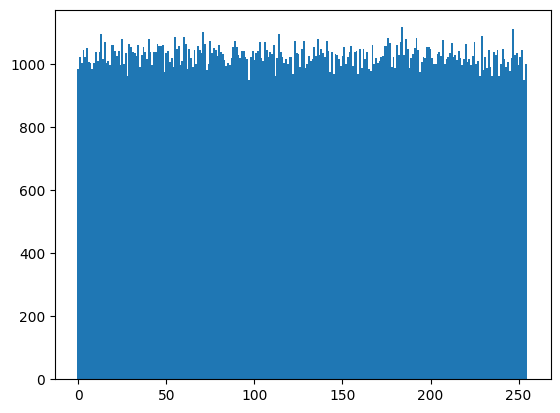

In [6]:
# Histograma implementado
hist_computado=computa_histograma(img)
print(hist_computado)
#plt.bar(range(0, 256), hist_computado) # há distancia entre as barras, usar outros parametros e tirar bordas/distância
plt.bar(range(0, 256), hist_computado, linewidth=0, width=1) # testes, facecolor='black', edgecolor='black')

In [7]:
def computa_histograma2(img):
    """Computa um histograma simples - veja em Burger/2016 e slides da aula de 04/08
    
    Args:
        img: WxH array de inteiros int. Imagem de entrada.
        
    Retorna:
        h: array numpy de 256 inteiros int. Histograma da imagem.
    """

    W, H = img.shape

    h = np.zeros((256), np.uint64)
    for v in range(0,H):
        for u in range(0,W):
            h[img[u,v]] += 1
    
    return h

[ 986 1024 1004 1046 1023 1051 1008 1005  985 1004 1040 1010 1037 1095
 1015 1069 1005 1010  998 1061 1061 1042 1026 1042  998 1080 1002 1035
  961 1065 1055 1040 1036 1027 1061  990 1029 1053 1039 1016 1080 1038
  996 1038 1039 1063 1058 1058 1060  974 1034 1041 1008 1020  992 1086
 1048 1059  998 1011 1085 1064  986 1047 1020  990 1044 1001 1059 1045
 1036 1102 1063  980 1002 1073 1034 1051 1044 1027 1061 1040 1032 1013
  995 1005  998 1020 1054 1074 1056 1028 1018 1042 1041 1023 1017  951
 1023 1043 1012 1035 1041 1069 1021 1009 1071 1046 1024 1037 1031 1060
  962 1021 1097 1037 1023 1003 1017 1000 1024 1024  970 1074 1034 1033
  990 1048 1075  989 1001 1025 1011 1015 1053 1027 1079 1028 1048 1034
 1024 1075 1041  974 1037  970 1032 1030 1016  995 1027 1056 1000 1023
 1040 1059  995 1040 1041  969 1048  988 1049 1016 1039  984  977 1060
 1000 1021 1005 1009 1024 1027 1059 1057 1084 1068  991 1023  987 1061
 1029 1071 1117 1029 1081 1047  989 1021 1032 1051 1082 1045  976 1007
 1022 

<BarContainer object of 256 artists>

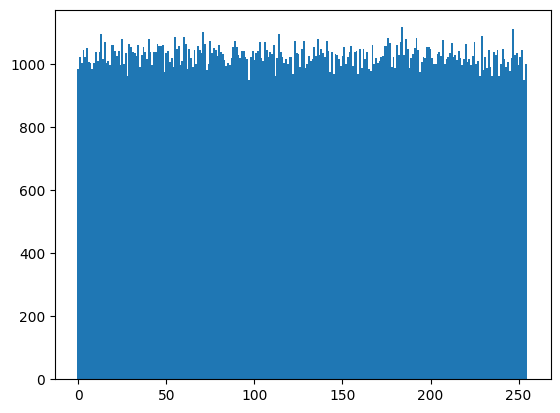

In [8]:
# Histograma implementado 2
hist_computado2=computa_histograma2(img)
print(hist_computado2)
#plt.bar(range(0, 256), hist_computado) # há distancia entre as barras, usar outros parametros e tirar bordas/distância
plt.bar(range(0, 256), hist_computado, linewidth=0, width=1) # testes, facecolor='black', edgecolor='black')